# Training

Localizing the focal liver lesion is framed as **dense segmentation** (lesion vs liver), which generalizes far better than box detection on these small, low-contrast lesions. Each method gets its own section; below is **Method 1: nnU-Net**.

## Method 1 — nnU-Net (2D lesion segmentation)

[nnU-Net](https://github.com/MIC-DKFZ/nnUNet) is a self-configuring segmentation framework — it inspects the dataset and picks the architecture, patch size, normalization and augmentation automatically. It is the standard strong baseline for medical image segmentation.

**How we run it here**
1. **Build examples** — for each patient we take the annotated `0_0.dcm` frame, de-identify it (keep only the ultrasound sector), and pair it with the lesion mask rasterized from the spline contour (`usloc.labels.register_case`). One frame per patient keeps nnU-Net's internal 5-fold CV patient-clean.
2. **Export to nnU-Net format** (`usloc.datasets.export_nnunet`): Dresden → `imagesTr/labelsTr`, Halle → `imagesTs/labelsTs` (locked external test). Binary labels: `background=0, lesion=1`.
3. **Plan & preprocess** — nnU-Net configures an **8-stage 2D U-Net** (patch 448×896, z-score normalization, batch 4).
4. **Train** fold 0 for 100 epochs (`torch.compile` disabled for this GPU).
5. **Evaluate** — nnU-Net's held-out Dresden val split, and inference on the Halle external test.

**Results so far (fold 0):** peak validation Dice ≈ **0.16** (the model overfits after ~epoch 21 given only ~83 unique training images); **Halle external mean Dice ≈ 0.08, detection rate ≈ 17%** (Dice>0.1). Localization is genuinely data-limited — honest baseline numbers to improve on (5-fold ensemble, tighter/higher-res ROI, more data).

In [1]:
%matplotlib inline
import json, warnings; warnings.simplefilter('ignore')
import numpy as np, cv2, matplotlib.pyplot as plt
from usloc import config as C
from usloc.viz import overlay_mask
plt.rcParams.update({'figure.dpi':110,'font.size':9,'axes.titlesize':9,'figure.facecolor':'white'})

NN = C.DERIVED/'nnunet'
RAW = NN/'raw'/'Dataset001_Lesion'
split = json.load(open(NN/'preprocessed'/'Dataset001_Lesion'/'splits_final.json'))[0]
train_cases, val_cases = split['train'], split['val']
test_cases = sorted(p.name[:-9] for p in (RAW/'imagesTs').glob('*_0000.png'))
print(f'fold-0  train={len(train_cases)}  val={len(val_cases)}  |  Halle test={len(test_cases)}')

def gray(case, img_sub):
    p = RAW/img_sub/f'{case}_0000.png'
    return cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) if p.exists() else None
def gt(case, lab_sub):
    p = RAW/lab_sub/f'{case}.png'
    m = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    return (m>0).astype('uint8') if m is not None else None
def pred(case, folder):
    p = NN/folder/f'{case}.png'
    m = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    return (m>0).astype('uint8') if m is not None else None
def dice(a,b):
    a,b = a>0, b>0; d = a.sum()+b.sum(); return 1.0 if d==0 else float(2*(a&b).sum()/d)


fold-0  train=83  val=21  |  Halle test=36


### The data that goes into the model
This is exactly what nnU-Net sees: the de-identified B-mode frame with the lesion mask (cyan) + its bounding box (yellow), kept strictly separate between the **train** and **val** patients of fold 0.

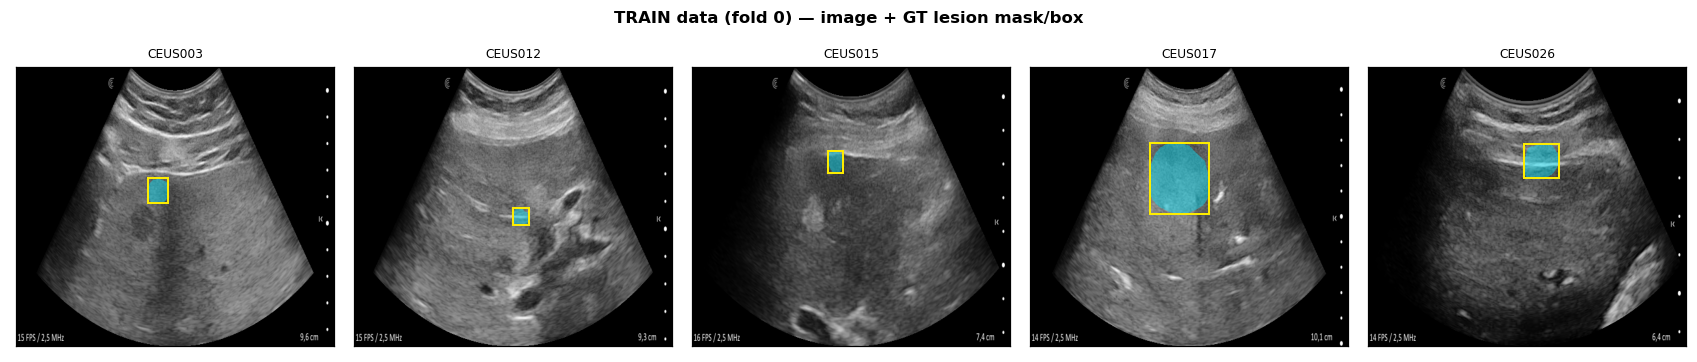

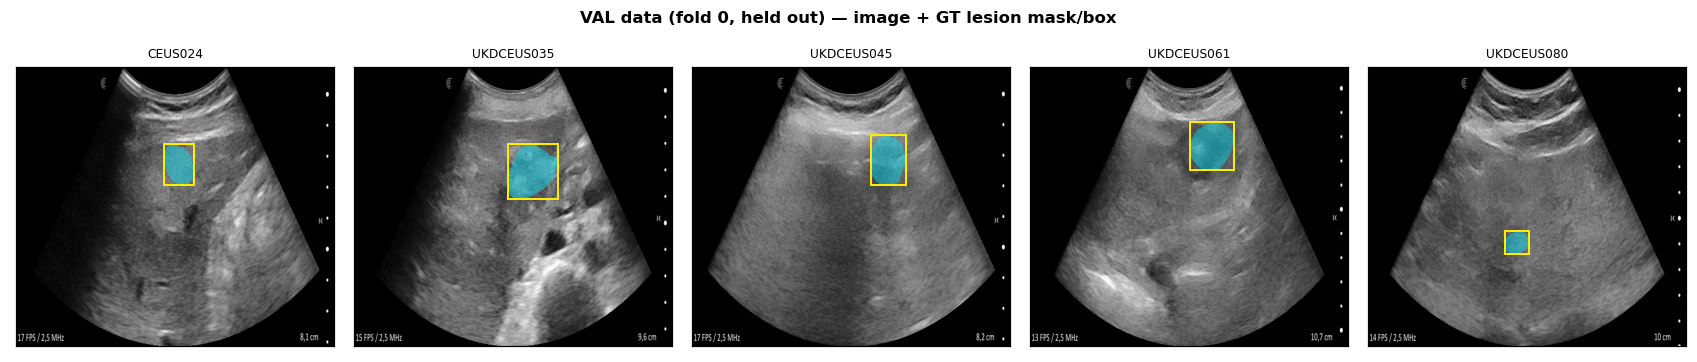

In [2]:
from matplotlib.patches import Rectangle
def show_gt_grid(cases, img_sub, lab_sub, title, n=5):
    cases = cases[:n]
    fig, ax = plt.subplots(1, len(cases), figsize=(3.1*len(cases), 3.3))
    if len(cases)==1: ax=[ax]
    for a, c in zip(ax, cases):
        g, m = gray(c, img_sub), gt(c, lab_sub)
        if g is None or m is None: a.axis('off'); continue
        a.imshow(overlay_mask(g, m, (0,229,255), 0.45), aspect='auto')
        ys,xs = np.where(m)
        if len(xs):
            a.add_patch(Rectangle((xs.min(),ys.min()), xs.max()-xs.min(), ys.max()-ys.min(),
                                  fill=False, edgecolor='#ffee00', lw=1.3))
        a.set_xticks([]); a.set_yticks([]); a.set_title(c, fontsize=8)
    fig.suptitle(title, fontweight='bold'); plt.tight_layout(); plt.show()

show_gt_grid(train_cases, 'imagesTr', 'labelsTr', 'TRAIN data (fold 0) — image + GT lesion mask/box', n=5)
show_gt_grid(val_cases,  'imagesTr', 'labelsTr', 'VAL data (fold 0, held out) — image + GT lesion mask/box', n=5)


### Straight out of the model — predicted segmentation
For each case: the raw input, the ground-truth lesion, and the **model's predicted mask** (magenta). Per-case Dice is shown. First the held-out **Dresden val**, then the **Halle external** test (a different hospital the model never saw).

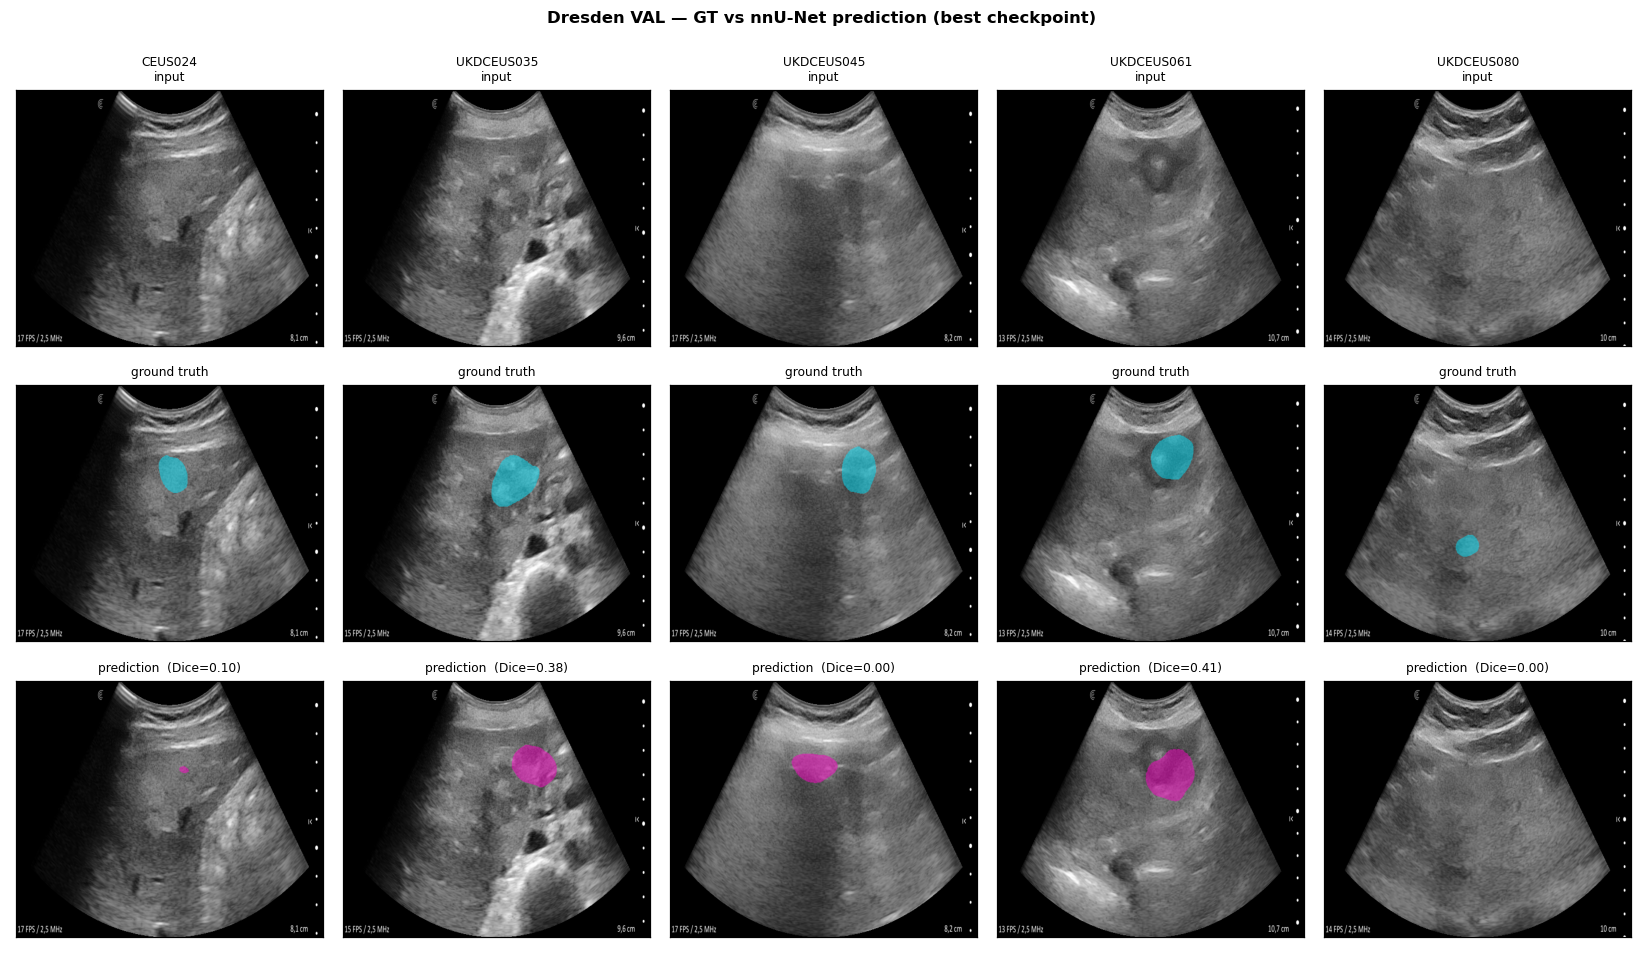

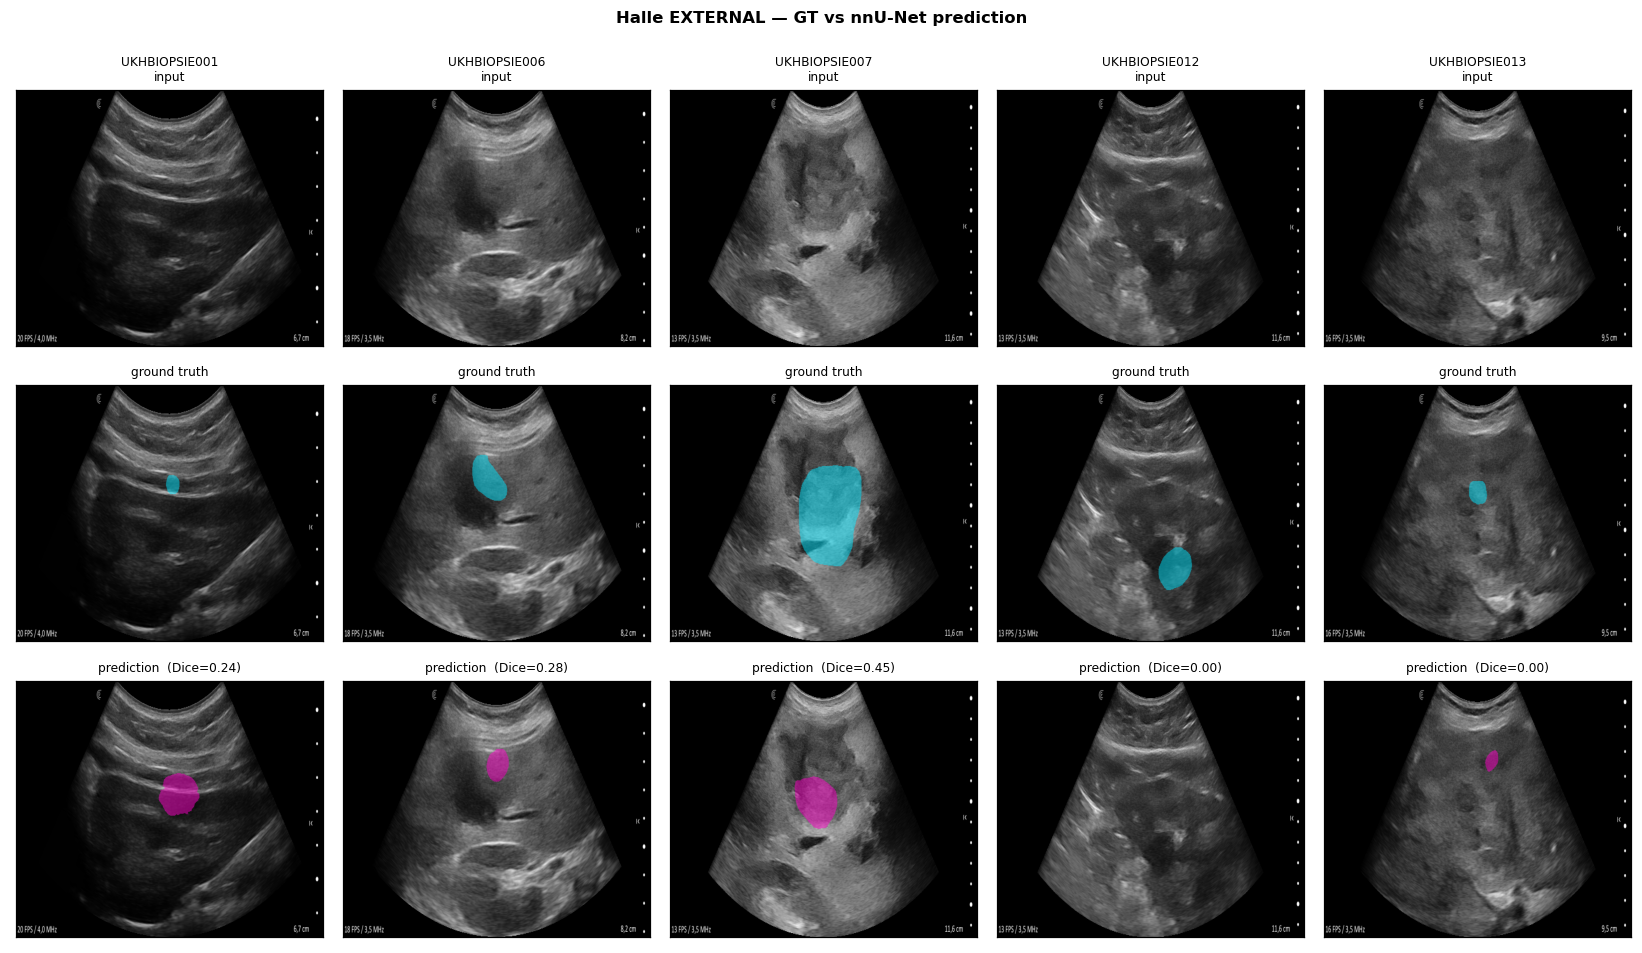

In [3]:
def show_pred_grid(cases, img_sub, lab_sub, pred_folder, title, n=5):
    cases = [c for c in cases if pred(c, pred_folder) is not None][:n]
    fig, ax = plt.subplots(3, len(cases), figsize=(3.0*len(cases), 8.6))
    for j, c in enumerate(cases):
        g, m, pr = gray(c, img_sub), gt(c, lab_sub), pred(c, pred_folder)
        col = ax[:, j] if len(cases)>1 else ax
        col[0].imshow(g, cmap='gray', aspect='auto'); col[0].set_title(f'{c}\ninput', fontsize=8)
        col[1].imshow(overlay_mask(g, m, (0,229,255), 0.5), aspect='auto'); col[1].set_title('ground truth', fontsize=8)
        col[2].imshow(overlay_mask(g, pr, (255,0,200), 0.5), aspect='auto')
        col[2].set_title(f'prediction  (Dice={dice(pr,m):.2f})', fontsize=8)
        for a in col: a.set_xticks([]); a.set_yticks([])
    fig.suptitle(title, fontweight='bold', y=1.0); plt.tight_layout(); plt.show()

show_pred_grid(val_cases, 'imagesTr', 'labelsTr', 'pred_val', 'Dresden VAL — GT vs nnU-Net prediction (best checkpoint)', n=5)
show_pred_grid(test_cases, 'imagesTs', 'labelsTs', 'pred_halle', 'Halle EXTERNAL — GT vs nnU-Net prediction', n=5)


### Takeaways
- The **GT panels confirm the pipeline is correct** — masks/boxes sit on real lesions, cleanly split between train and val patients.
- Predictions land on some Dresden val lesions but **collapse on Halle external** (mean Dice ≈ 0.08, ~17% detected) — localization is limited by only ~140 unique lesions and subtle B-mode appearance, not by the pipeline.
- **Next:** 5-fold ensemble, tighter/higher-resolution lesion ROI, patient-grouped multi-frame data, and RF/QUS channels. The stage-2 **benign/malignant classifier** already works (0.90 Dresden / 0.65 Halle) and pairs with this as a two-stage system.